# All 9 Model Combinations — Single Day

Prediction maps for all 9 (transform × variogram) configurations on a single day.

In [1]:
import os
import pickle
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── CONFIG ───────────────────────────────────────────────────────────────────
TEST_DATE = "2013-02-01"

ROOT = Path(os.getcwd())
if ROOT.name in ("notebooks", "03_results"):
    ROOT = ROOT.parent if ROOT.name == "notebooks" else ROOT.parent.parent
DIR_OUT = ROOT / "results" / "viz_day"

TRANSFORMS   = ["none", "log", "normal_score"]
MODELS       = ["spherical", "exponential", "gaussian"]
TR_LABELS    = {"none": "Raw quota", "log": "Log", "normal_score": "NST"}
MODEL_LABELS = {"spherical": "Spherical", "exponential": "Exponential", "gaussian": "Gaussian"}

# ── rcParams ─────────────────────────────────────────────────────────────────
mpl.rcParams.update({
    "font.family":         "serif",
    "font.serif":          ["DejaVu Serif", "Times New Roman", "Times"],
    "font.size":           9,
    "axes.titlesize":      9,
    "axes.labelsize":      8,
    "xtick.labelsize":     7,
    "ytick.labelsize":     7,
    "legend.fontsize":     8,
    "figure.dpi":          100,
    "savefig.dpi":         300,
    "savefig.bbox":        "tight",
    "axes.linewidth":      0.5,
    "xtick.major.width":   0.5,
    "ytick.major.width":   0.5,
    "xtick.major.size":    2.5,
    "ytick.major.size":    2.5,
    "image.interpolation": "none",
})

CMAP_PRECIP  = "YlGnBu"    # yellow→green→blue: standard met precipitation
CMAP_STD     = "Oranges"   # sequential warm: kriging standard error
CMAP_HEATMAP = "RdYlGn_r"  # LOO-CV heatmap

# ── Helper: pixel coordinates of stations on the grid ────────────────────────
def station_pixel_coords(grid_meta, stations, shape):
    cx = grid_meta["coords_proj"][:, 0]
    cy = grid_meta["coords_proj"][:, 1]
    x0, y0 = cx.min(), cy.min()
    dx = (cx.max() - x0) / shape[1]
    dy = (cy.max() - y0) / shape[0]
    sx = (stations["x_proj"] - x0) / dx
    sy = (stations["y_proj"] - y0) / dy
    return sx, sy

# ── Helper: clean map axes (no ticks, no spines, keep ylabel) ────────────────
def clean_map_ax(ax):
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

print(f"ROOT    : {ROOT}")
print(f"Outputs : {DIR_OUT}")
print(f"Date    : {TEST_DATE}")

ROOT    : /Users/etomengoi/Desktop/precip_interpolation_thesis
Outputs : /Users/etomengoi/Desktop/precip_interpolation_thesis/results/viz_day
Date    : 2013-02-01


In [2]:
# ── Load pkl outputs ──────────────────────────────────────────────────────────
def load_pkl(name: str) -> dict:
    path = DIR_OUT / f"{name}_{TEST_DATE}.pkl"
    if not path.exists():
        raise FileNotFoundError(
            f"{path.name} not found.\n"
            f"Run: python -m thesis.scripts.run_viz_day --date {TEST_DATE} --no-upload"
        )
    with open(path, "rb") as f:
        return pickle.load(f)

predictions = load_pkl("predictions")
variances   = load_pkl("variances")
grid_meta   = load_pkl("grid_meta")
stations    = load_pkl("stations")

loo_cv_path = DIR_OUT / f"loo_cv_{TEST_DATE}.pkl"
loo_results = pickle.load(open(loo_cv_path, "rb")) if loo_cv_path.exists() else {}

shape     = tuple(grid_meta["shape"])
wet_grid  = grid_meta["wet_grid"]
n_wet_stn = int(stations["rain_indicator"].sum())
n_stn     = len(stations["rain_indicator"])

# Shared colour scale: 0 – p98 across all models
all_wet_vals = np.concatenate([v[wet_grid] for v in predictions.values()])
VMIN_PRECIP  = 0.0
VMAX_PRECIP  = float(np.percentile(all_wet_vals, 98))

print(f"Grid   : {shape[0]}×{shape[1]} = {shape[0]*shape[1]:,} cells")
print(f"Wet    : {wet_grid.sum():,} cells  |  {n_wet_stn}/{n_stn} stations wet")
print(f"p98    : {VMAX_PRECIP:.2f} mm")
print(f"LOO-CV : {'yes' if loo_results else 'no'}")

Grid   : 439×432 = 189,648 cells
Wet    : 189,648 cells  |  2458/2458 stations wet
p98    : 12.99 mm
LOO-CV : yes


## Figure 1. Prediction maps — all 9 configurations

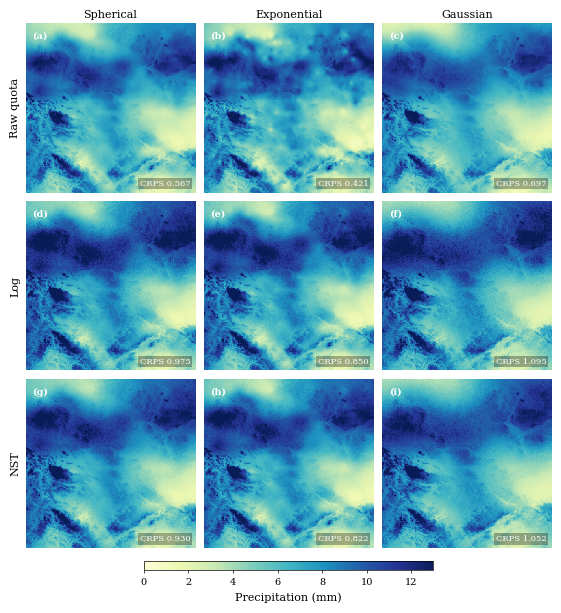

In [3]:
PANEL_LABELS = [chr(ord('a') + k) for k in range(9)]

fig, axes = plt.subplots(
    3, 3,
    figsize=(5.5, 6.0),
    constrained_layout=True,
)

last_im = None
for i, tr in enumerate(TRANSFORMS):
    for j, model in enumerate(MODELS):
        ax  = axes[i, j]
        key = (tr, model)
        pred = predictions.get(key)

        if pred is None:
            ax.set_visible(False)
            continue

        im = ax.imshow(
            pred.reshape(shape),
            origin="lower", cmap=CMAP_PRECIP,
            vmin=VMIN_PRECIP, vmax=VMAX_PRECIP,
            aspect="auto",
        )
        last_im = im

        # Clean axes: hide ticks/spines but keep ylabel slot alive
        clean_map_ax(ax)

        # Column header — top row only
        if i == 0:
            ax.set_title(MODEL_LABELS[model], fontsize=8, pad=4)

        # Row label — left column only, via set_ylabel (works because spines hidden not axis off)
        if j == 0:
            ax.set_ylabel(TR_LABELS[tr], fontsize=8, labelpad=4)

        # Panel label
        idx = i * 3 + j
        ax.text(
            0.04, 0.95, f"({PANEL_LABELS[idx]})",
            transform=ax.transAxes,
            fontsize=7, va="top", ha="left",
            color="white", fontweight="bold",
        )

        # CRPS annotation
        if loo_results and key in loo_results:
            crps = loo_results[key]["crps_mm"]
            ax.text(
                0.97, 0.03, f"CRPS {crps:.3f}",
                transform=ax.transAxes,
                fontsize=6, va="bottom", ha="right", color="white",
                bbox=dict(facecolor="black", alpha=0.3, pad=1.2, linewidth=0),
            )

# Shared colorbar below the grid
cb = fig.colorbar(
    last_im, ax=axes,
    orientation="horizontal",
    shrink=0.55, aspect=30, pad=0.02,
)
cb.set_label("Precipitation (mm)", fontsize=8)
cb.ax.tick_params(labelsize=7, width=0.5, length=2)
cb.outline.set_linewidth(0.5)

plt.show()

## Figure 2. Best model — predicted field and kriging standard error

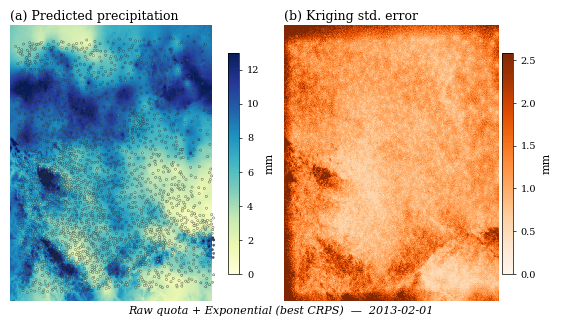

Best key: ('none', 'exponential')


In [4]:
if loo_results:
    best_key  = min(loo_results, key=lambda k: loo_results[k]["crps_mm"])
    best_note = f"{TR_LABELS[best_key[0]]} + {MODEL_LABELS[best_key[1]]} (best CRPS)"
else:
    best_key  = ("normal_score", "exponential")
    best_note = f"{TR_LABELS[best_key[0]]} + {MODEL_LABELS[best_key[1]]} (default)"

pred_best = predictions[best_key].reshape(shape)
std_best  = np.sqrt(np.maximum(variances[best_key], 0)).reshape(shape)
vmax_std  = float(np.percentile(std_best[std_best > 0], 98))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(5.5, 3.0), constrained_layout=True)

sx, sy  = station_pixel_coords(grid_meta, stations, shape)
wet_stn = stations["rain_indicator"] == 1

# (a) Predicted precipitation
im1 = ax1.imshow(pred_best, origin="lower",
                 cmap=CMAP_PRECIP, vmin=0, vmax=VMAX_PRECIP, aspect="auto")
ax1.scatter(sx[wet_stn], sy[wet_stn],
            c=stations["precip_mm"][wet_stn],
            cmap=CMAP_PRECIP, vmin=0, vmax=VMAX_PRECIP,
            s=2.5, linewidths=0.25, edgecolors="#333333", zorder=3)
ax1.scatter(sx[~wet_stn], sy[~wet_stn],
            s=1.5, facecolors="none", edgecolors="#aaaaaa", linewidths=0.2, zorder=2)
clean_map_ax(ax1)
ax1.set_title("(a) Predicted precipitation", fontsize=9, loc="left", pad=4)
cb1 = fig.colorbar(im1, ax=ax1, shrink=0.8, aspect=20, pad=0.02)
cb1.set_label("mm", fontsize=8)
cb1.ax.tick_params(labelsize=7, width=0.5, length=2)
cb1.outline.set_linewidth(0.5)

# (b) Kriging standard error
im2 = ax2.imshow(std_best, origin="lower",
                 cmap=CMAP_STD, vmin=0, vmax=vmax_std, aspect="auto")
clean_map_ax(ax2)
ax2.set_title("(b) Kriging std. error", fontsize=9, loc="left", pad=4)
cb2 = fig.colorbar(im2, ax=ax2, shrink=0.8, aspect=20, pad=0.02)
cb2.set_label("mm", fontsize=8)
cb2.ax.tick_params(labelsize=7, width=0.5, length=2)
cb2.outline.set_linewidth(0.5)

fig.suptitle(f"{best_note}  —  {TEST_DATE}", fontsize=8, style="italic", y=0.0)
plt.show()
print(f"Best key: {best_key}")

## Figure 3. LOO-CV performance heatmap

Rendered only when `--loo-cv` was passed to `run_viz_day.py`.

In [ ]:
if not loo_results:
    print("No LOO-CV data. Re-run with --loo-cv to enable this figure.")
else:
    mae_mat  = np.full((3, 3), np.nan)
    crps_mat = np.full((3, 3), np.nan)
    for i, tr in enumerate(TRANSFORMS):
        for j, model in enumerate(MODELS):
            key = (tr, model)
            if key in loo_results:
                mae_mat[i, j]  = loo_results[key]["mae_mm"]
                crps_mat[i, j] = loo_results[key]["crps_mm"]

    tr_tick    = [TR_LABELS[t]    for t in TRANSFORMS]
    model_tick = [MODEL_LABELS[m] for m in MODELS]

    fig, axes = plt.subplots(1, 2, figsize=(5.5, 2.4), constrained_layout=True)

    heatmap_kw = dict(
        annot=True, fmt=".3f", annot_kws={"size": 8},
        cmap=CMAP_HEATMAP,
        linewidths=0.4, linecolor="white",
        cbar_kws={"shrink": 0.9, "aspect": 12},
    )

    for ax, mat, subtitle in [
        (axes[0], mae_mat,  "(a) MAE (mm)"),
        (axes[1], crps_mat, "(b) CRPS (mm)"),
    ]:
        sns.heatmap(mat, ax=ax,
                    xticklabels=model_tick, yticklabels=tr_tick,
                    **heatmap_kw)
        ax.set_title(subtitle, fontsize=9, loc="left", pad=4)
        ax.tick_params(labelsize=8, length=0)
        ax.set_xlabel("Variogram model", fontsize=8)
        ax.set_ylabel("Transform", fontsize=8)

        # Highlight best cell
        bi, bj = np.unravel_index(np.nanargmin(mat), mat.shape)
        ax.add_patch(plt.Rectangle(
            (bj, bi), 1, 1,
            fill=False, edgecolor="#1a1a2e", lw=1.8, zorder=5,
        ))

    plt.show()

    # Ranked table
    rows = [
        {
            "Transform": TR_LABELS[tr],
            "Variogram": MODEL_LABELS[model],
            "N": r["n"],
            "MAE (mm)": round(r["mae_mm"],  4),
            "CRPS (mm)": round(r["crps_mm"], 4),
        }
        for (tr, model), r in sorted(loo_results.items(), key=lambda x: x[1]["crps_mm"])
    ]
    df = pd.DataFrame(rows)
    display(
        df.style
          .highlight_min(subset=["MAE (mm)", "CRPS (mm)"], color="#cce5ff")
          .format({"MAE (mm)": "{:.4f}", "CRPS (mm)": "{:.4f}"})
    )

## Figure 4. Observed vs. predicted at station locations (best model)

In [ ]:
from scipy.spatial import cKDTree

coords   = grid_meta["coords_proj"]
wet_mask = stations["rain_indicator"] == 1

tree = cKDTree(coords)
_, nearest_idx = tree.query(
    np.column_stack([stations["x_proj"], stations["y_proj"]]), k=1
)
pred_at_stn = predictions[best_key][nearest_idx]

obs_wet  = stations["precip_mm"][wet_mask]
pred_wet = pred_at_stn[wet_mask]

mae_approx  = float(np.mean(np.abs(obs_wet - pred_wet)))
corr_approx = float(np.corrcoef(obs_wet, pred_wet)[0, 1])
lim = float(max(obs_wet.max(), pred_wet.max())) * 1.05

fig, ax = plt.subplots(figsize=(3.2, 3.2), constrained_layout=True)

ax.scatter(obs_wet, pred_wet,
           s=7, alpha=0.45, color="#2166ac", edgecolors="none")
ax.plot([0, lim], [0, lim], color="#d73027", lw=0.9, ls="--", label="1:1")

ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_xlabel("Observed (mm)")
ax.set_ylabel("Kriging, nearest cell (mm)")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, fontsize=7)
ax.grid(True, lw=0.35, alpha=0.5)

ax.text(0.97, 0.05,
        f"MAE = {mae_approx:.2f} mm\n$r$ = {corr_approx:.3f}",
        transform=ax.transAxes, fontsize=7.5, va="bottom", ha="right",
        bbox=dict(facecolor="white", edgecolor="#cccccc",
                  boxstyle="round,pad=0.3", lw=0.5))

ax.set_title(
    f"{TEST_DATE} — {TR_LABELS[best_key[0]]} + {MODEL_LABELS[best_key[1]]}",
    fontsize=8, loc="left", pad=4,
)
plt.show()

## Summary

In [ ]:
print(f"Date          : {TEST_DATE}")
print(f"Stations      : {n_wet_stn}/{n_stn} wet  ({100*n_wet_stn/n_stn:.1f}%)")
print(f"Wet cells     : {wet_grid.sum():,}/{len(wet_grid):,}  ({100*wet_grid.mean():.1f}%)")
print(f"Best config   : {best_key}  [{best_note}]")
if loo_results and best_key in loo_results:
    r = loo_results[best_key]
    print(f"LOO-CV MAE    : {r['mae_mm']:.4f} mm  |  CRPS: {r['crps_mm']:.4f} mm  |  N={r['n']}")
print(f"Pred range    : 0 – {max(v.max() for v in predictions.values()):.2f} mm")
print(f"Std range     : 0 – {max(np.sqrt(np.maximum(v,0)).max() for v in variances.values()):.2f} mm")